In [35]:
import  numpy as np
import pandas as pd
import  matplotlib.pyplot as plt
import seaborn as sns


In [36]:
df=pd.read_csv('bangladesh_student_performance_updated.csv')

In [37]:
df.shape

(2018, 16)

In [38]:
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
649,29/04/2018,M,17.0,Urban,GT3,Together,3,3,Services,Health,No,No,122710.0,5,3.35,2.91
1046,29/04/2018,M,17.0,Rural,GT3,Together,0,2,At_home,Health,Yes,No,40070.0,1,3.89,3.21
511,29/04/2018,M,17.0,Urban,LE3,Together,1,1,At_home,Teacher,No,No,99224.0,1,2.88,2.58
1846,29/04/2018,M,17.0,Urban,LE3,Together,3,0,Health,Teacher,Yes,No,103170.0,4,4.73,4.12
864,29/04/2018,M,18.0,Rural,GT3,Apart,1,3,Health,Health,No,No,48437.0,4,3.77,3.35
1341,29/04/2018,M,18.0,Rural,GT3,Together,2,3,At_home,Business,No,Yes,60090.0,3,4.04,3.41
717,29/04/2018,F,19.0,Urban,LE3,Together,0,1,Other,Services,No,Yes,98308.0,1,5.00,4.53
1646,29/04/2018,M,18.0,Urban,LE3,Apart,2,1,Other,Business,No,No,79334.0,3,3.70,2.91
833,29/04/2018,M,17.0,Rural,LE3,Together,2,3,Teacher,Services,No,No,71258.0,5,3.77,2.94
524,29/04/2018,F,17.0,Rural,LE3,Apart,0,0,At_home,Services,No,No,26858.0,2,4.92,4.21


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [40]:
df['time_friends'].unique()

array([4, 5, 3, 2, 1], dtype=int64)

In [41]:
df['M_Edu'].unique()

array([3, 0, 2, 1, 4], dtype=int64)

In [42]:
df.isnull().sum()

date             0
gender           0
age             35
address         35
famsize          0
Pstatus          0
M_Edu            0
F_Edu            0
M_Job           35
F_Job            0
relationship     0
smoker           0
tuition_fee     35
time_friends     0
ssc_result       0
hsc_result       0
dtype: int64

In [43]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

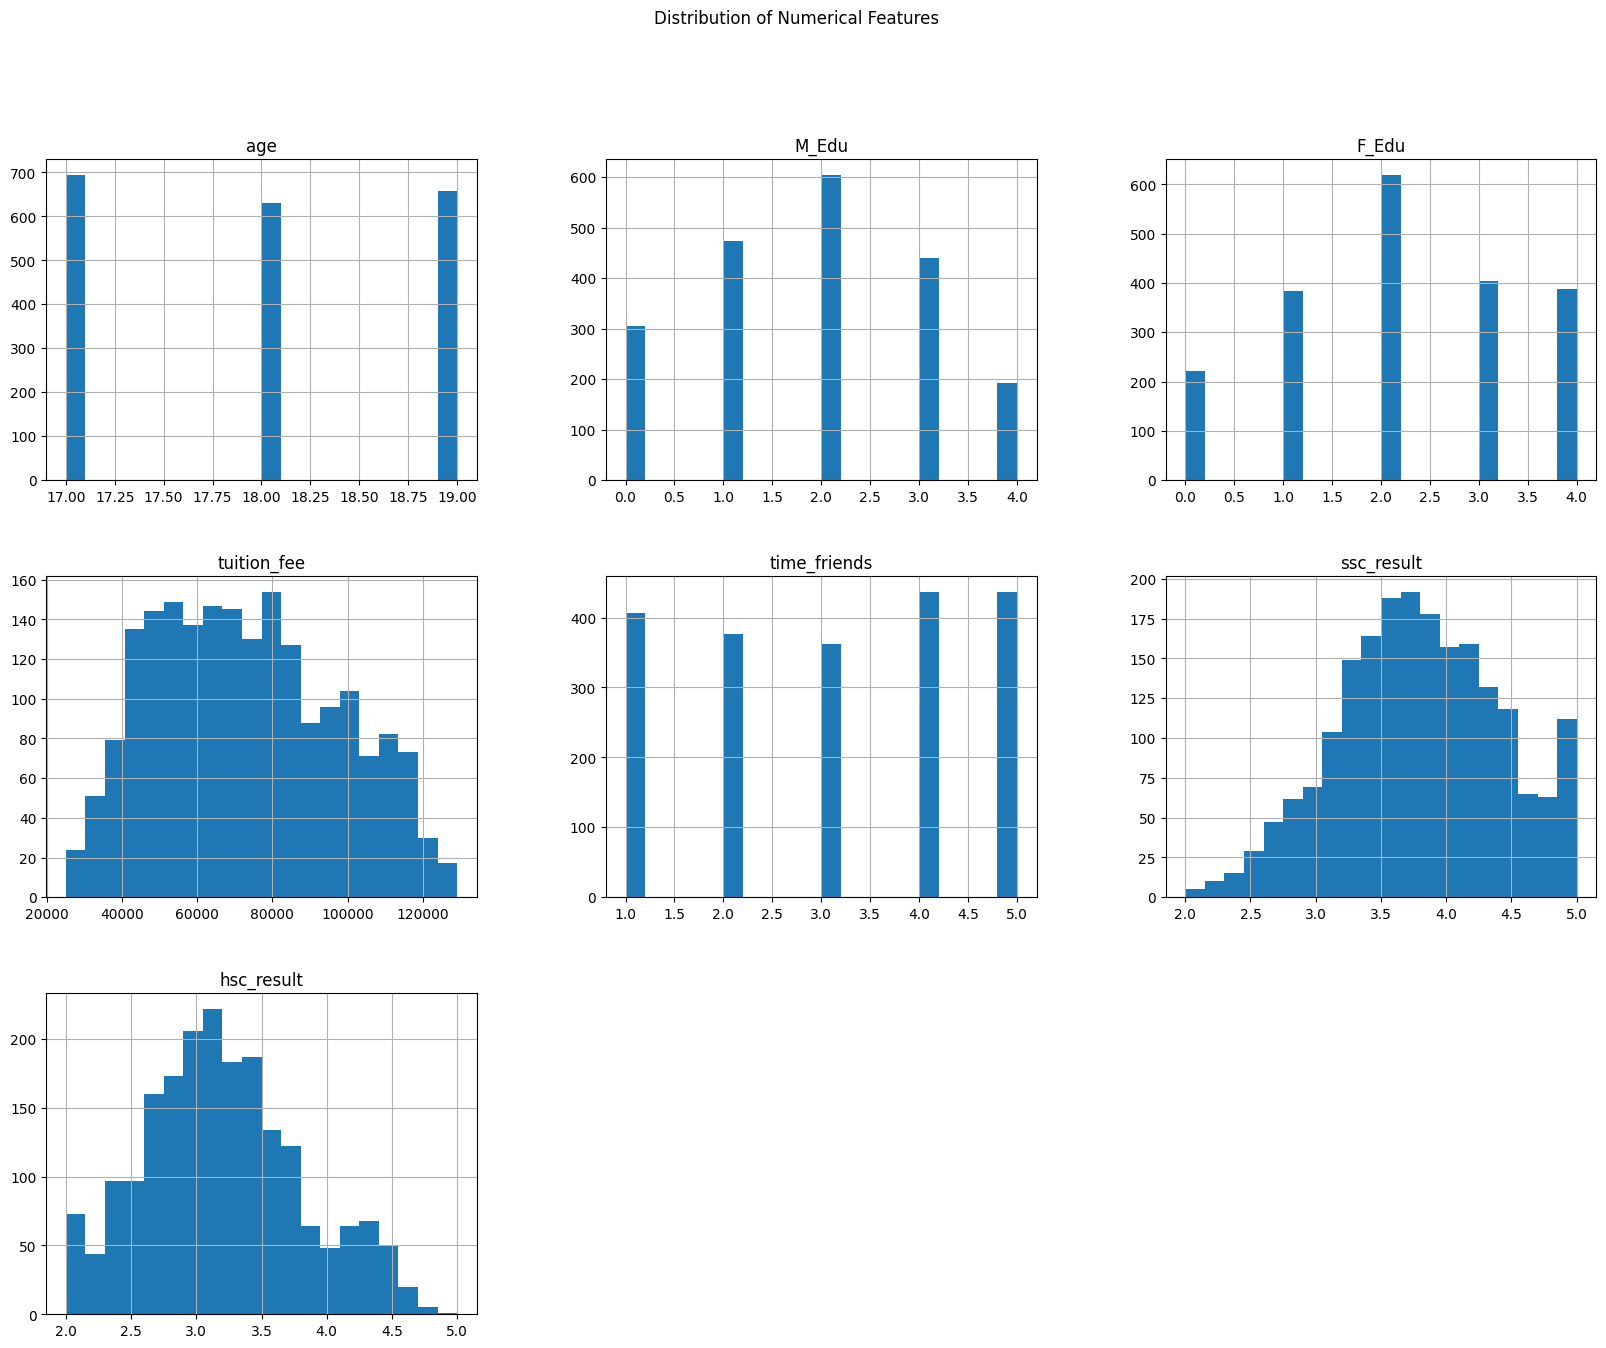

In [44]:
df.hist(bins=20, figsize=(20,15))
plt.suptitle("Distribution of Numerical Features")
plt.show()

In [45]:
#correlation matrix
numerical_cols=['age','tuition_fee','ssc_result','hsc_result']
df[numerical_cols].corr()


,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


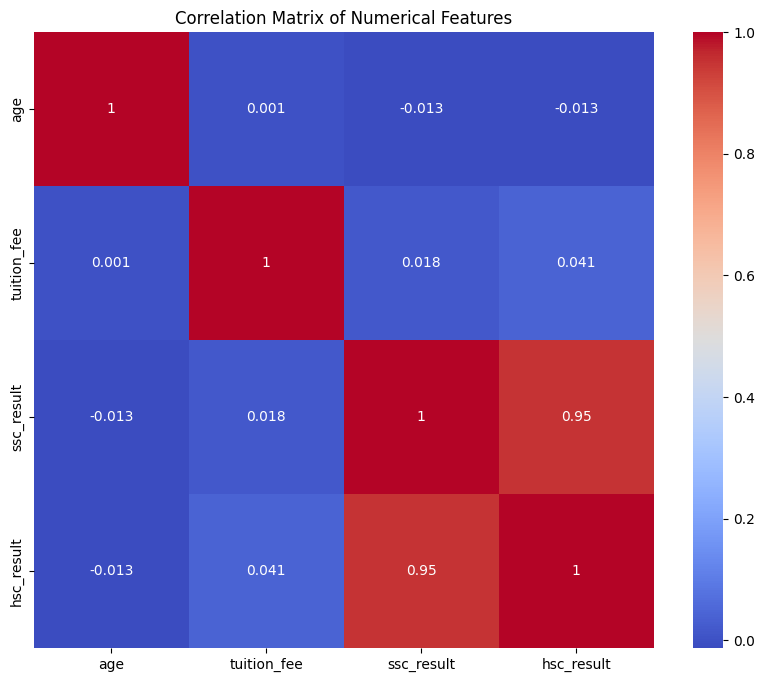

In [46]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

<Axes: xlabel='ssc_result'>

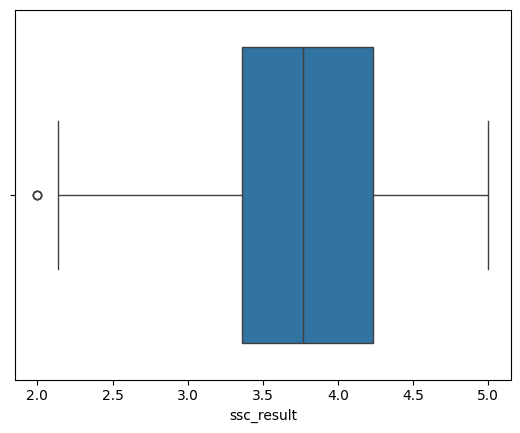

In [47]:
sns.boxplot(data=df, x='ssc_result')

preprocessing

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder, LabelEncoder,MinMaxScaler
from sklearn.pipeline import Pipeline

In [49]:
nominal_cat=['gender','address','famsize','Pstatus','relationship','smoker','M_Job','F_Job']
numerical_cols=['age','tuition_fee','ssc_result']

numerical_transformers=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
]) 

In [50]:
nominal_transformers=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    
])

In [51]:
#ordinal_transformers=Pipeline(
   # steps=[
   # ('imputer',SimpleImputer(strategy='most_frequent')),
   # ('encoder',OrdinalEncoder(categories=['M_edu_order','F_edu_order','time_friends_order'])),
    #('scaler',MinMaxScaler())
#])

In [52]:
preprocessor=ColumnTransformer(
    transformers=[
        ('numerical',numerical_transformers,numerical_cols),
        ('nominal',nominal_transformers,nominal_cat),
       # ('ordinal',ordinal_transformers,ordinal_cols)
    ]
)

In [53]:
x=df.drop(['date','hsc_result'],axis=1)
y=df['hsc_result']
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# LinearRegression

In [54]:
from sklearn.linear_model import LinearRegression,SGDRegressor


In [55]:
lr_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])
lr_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
X_test

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
1556,F,17.0,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743.0,1,3.88
526,M,19.0,Rural,GT3,Together,4,3,At_home,Business,No,No,58678.0,5,4.36
393,F,18.0,Urban,GT3,Together,2,1,Services,Services,No,No,115832.0,3,4.47
1789,M,17.0,Urban,GT3,Together,2,3,Health,Teacher,No,Yes,112781.0,1,4.43
433,M,19.0,Rural,LE3,Together,1,0,Teacher,Farmer,No,Yes,52481.0,4,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,M,17.0,Rural,GT3,Apart,1,4,Health,Teacher,No,No,60345.0,4,3.47
693,M,19.0,Urban,GT3,Together,1,2,Health,Business,No,No,85346.0,4,2.96
1494,F,18.0,Rural,LE3,Together,1,4,Teacher,Teacher,No,No,30638.0,1,3.76
921,M,NaN,Urban,GT3,Together,0,1,Teacher,Teacher,No,No,76804.0,2,4.18


In [57]:
lr_predictions=lr_pipeline.predict(X_test)
lr_predictions

array([3.17892133, 3.74910463, 3.88811172, 3.85765222, 4.06482416,
       3.31328793, 4.054158  , 2.36318231, 2.10350552, 3.32764446,
       3.62379467, 3.02426095, 3.21504521, 4.39041923, 3.15073066,
       2.59805377, 3.63708513, 3.32414691, 2.97370454, 3.00821882,
       2.81844629, 3.29497725, 3.14069559, 3.34162092, 2.08688416,
       2.58435581, 3.25355286, 3.73667551, 2.9575427 , 3.89017505,
       2.56784216, 3.83619288, 4.32958285, 2.61047911, 3.27915606,
       3.01160911, 2.80581142, 3.71831783, 2.4194444 , 2.4525508 ,
       3.13924832, 3.14176355, 3.77019056, 2.63475162, 2.27610124,
       3.07272131, 2.69080751, 2.65011938, 4.04587356, 3.34738089,
       3.04731239, 3.6123316 , 4.03744643, 3.70229884, 3.07654244,
       3.3871092 , 3.29103835, 2.7322619 , 3.88243512, 2.61177321,
       3.08098454, 2.79581057, 2.6430247 , 4.31966562, 2.6586807 ,
       3.30554527, 3.84984483, 2.61899586, 3.11383643, 3.2769989 ,
       3.09202261, 2.69005458, 2.63644324, 3.68357509, 3.09674

In [58]:
SGD_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',SGDRegressor())
]
)
SGD_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
sgd_predictions = SGD_pipeline.predict(X_test)
sgd_predictions

array([3.17771719, 3.74890221, 3.88780834, 3.79350992, 4.00645167,
       3.31457701, 4.01146743, 2.31989162, 2.10514314, 3.32736972,
       3.62627801, 3.02041642, 3.20824593, 4.38570971, 3.1537803 ,
       2.56076151, 3.64868209, 3.26709863, 2.97414258, 2.96437108,
       2.81978776, 3.29022382, 3.10431468, 3.30936363, 2.08820257,
       2.52761021, 3.2495191 , 3.73475303, 2.92482918, 3.88563799,
       2.56984271, 3.84031184, 4.29533068, 2.61078878, 3.27696504,
       3.01026931, 2.79887537, 3.72282   , 2.41717815, 2.44616428,
       3.13837476, 3.14105363, 3.77401718, 2.62681946, 2.21652413,
       3.06586394, 2.69246047, 2.64711271, 4.01459756, 3.31317281,
       3.04474061, 3.60742265, 3.99603415, 3.66743369, 3.08299916,
       3.34524043, 3.28622015, 2.72804179, 3.87641407, 2.54672924,
       3.09171369, 2.79195734, 2.64471947, 4.31561057, 2.66618045,
       3.2999543 , 3.81831121, 2.61630457, 3.1154337 , 3.24816653,
       3.08850622, 2.68887364, 2.6357844 , 3.69001023, 3.10558

Accuracy of the models

In [64]:
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error,mean_absolute_error

In [65]:
print("Linear Regression Performance:")
print("Mean Squared Error:", mean_squared_error(y_test, lr_predictions))
print("R-squared:", r2_score(y_test, lr_predictions))
print("Mean Absolute Error:", mean_absolute_error(y_test, lr_predictions))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, lr_predictions))

Linear Regression Performance:
Mean Squared Error: 0.031073668993707906
R-squared: 0.917094009859292
Mean Absolute Error: 0.1413240593510641
Root Mean Squared Error: 0.17627725035780398


In [66]:
print("SGD Regression Performance:")
print("Mean Squared Error:", mean_squared_error(y_test, sgd_predictions))
print("R-squared:", r2_score(y_test, sgd_predictions))
print("Mean Absolute Error:", mean_absolute_error(y_test, sgd_predictions))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, sgd_predictions))

SGD Regression Performance:
Mean Squared Error: 0.030841245485172194
R-squared: 0.9177141265603818
Mean Absolute Error: 0.1400462149016375
Root Mean Squared Error: 0.17561675741560712
